In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, roc_auc_score
)


In [2]:
# Import the Predict Students' Dropout and Academic Success dataset from GitHub
# Using the raw GitHub URL without token for better reliability
url = 'https://raw.githubusercontent.com/pratyushniraula/studentDataset/main/data.csv'
df = pd.read_csv(url, sep=';')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Check for nulls
print(df.isnull().sum())

# Handle missing data
df = df.fillna(df.median(numeric_only=True))

# Encode categorical columns
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [5]:
# Check summary stats
print(df.describe())

       Marital status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance\t  Previous qualification  \
count                   4424.000000             4424.000000   
mean                       0.890823                4.577758   
std                        0.311897               10.216592   
min                        0.000000                1.000000   
25%      

/Users/pratyushniraula/Documents/Work/Classes/CS_4372/classpackages/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/pratyushniraula/Documents/Work/Classes/CS_4372/classpackages/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


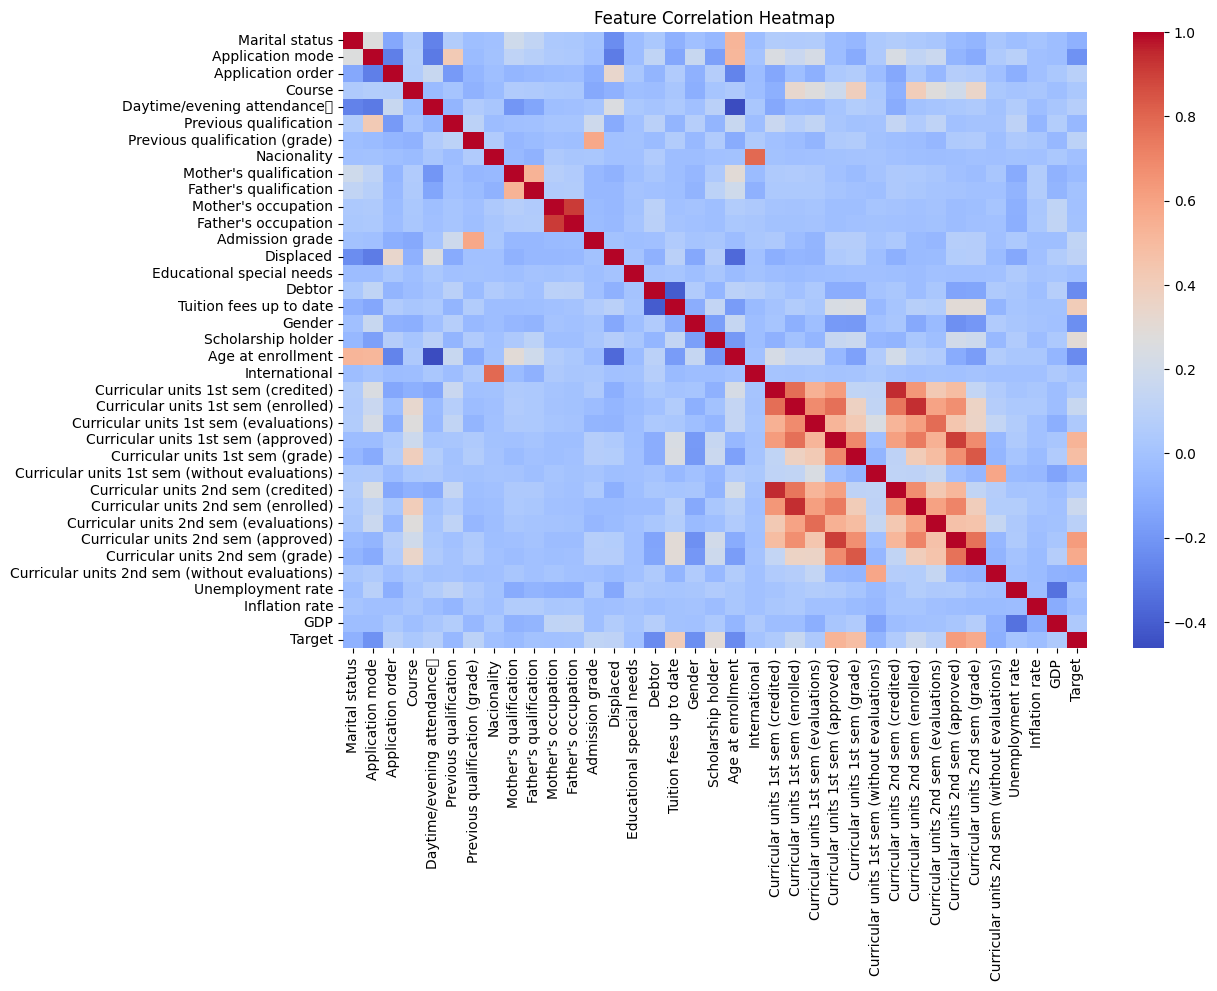

In [6]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()



In [7]:
# Standardize features
scaler = StandardScaler()
X = df.drop('Target', axis=1)  # Replace with correct target
y = df['Target']

X_scaled = scaler.fit_transform(X)

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (3539, 36) Test shape: (885, 36)


In [40]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt_params = {'max_depth':[3,5,10,None], 'criterion':['gini','entropy']}
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


Decision Tree Accuracy: 0.7559322033898305
Decision Tree Train Accuracy: 0.7745125741734953
Confusion Matrix:
 [[195  32  57]
 [ 29  54  76]
 [ 11  11 420]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       284
           1       0.56      0.34      0.42       159
           2       0.76      0.95      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



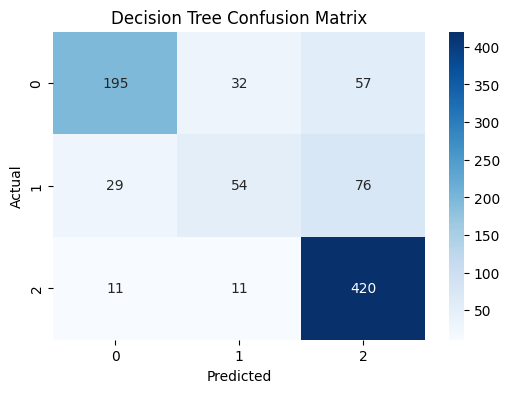

In [41]:
#predict and evaluate decision tree
y_pred_dt = dt_grid.predict(X_test)
y_train_pred_dt = dt_grid.predict(X_train)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Train Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
#visual heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

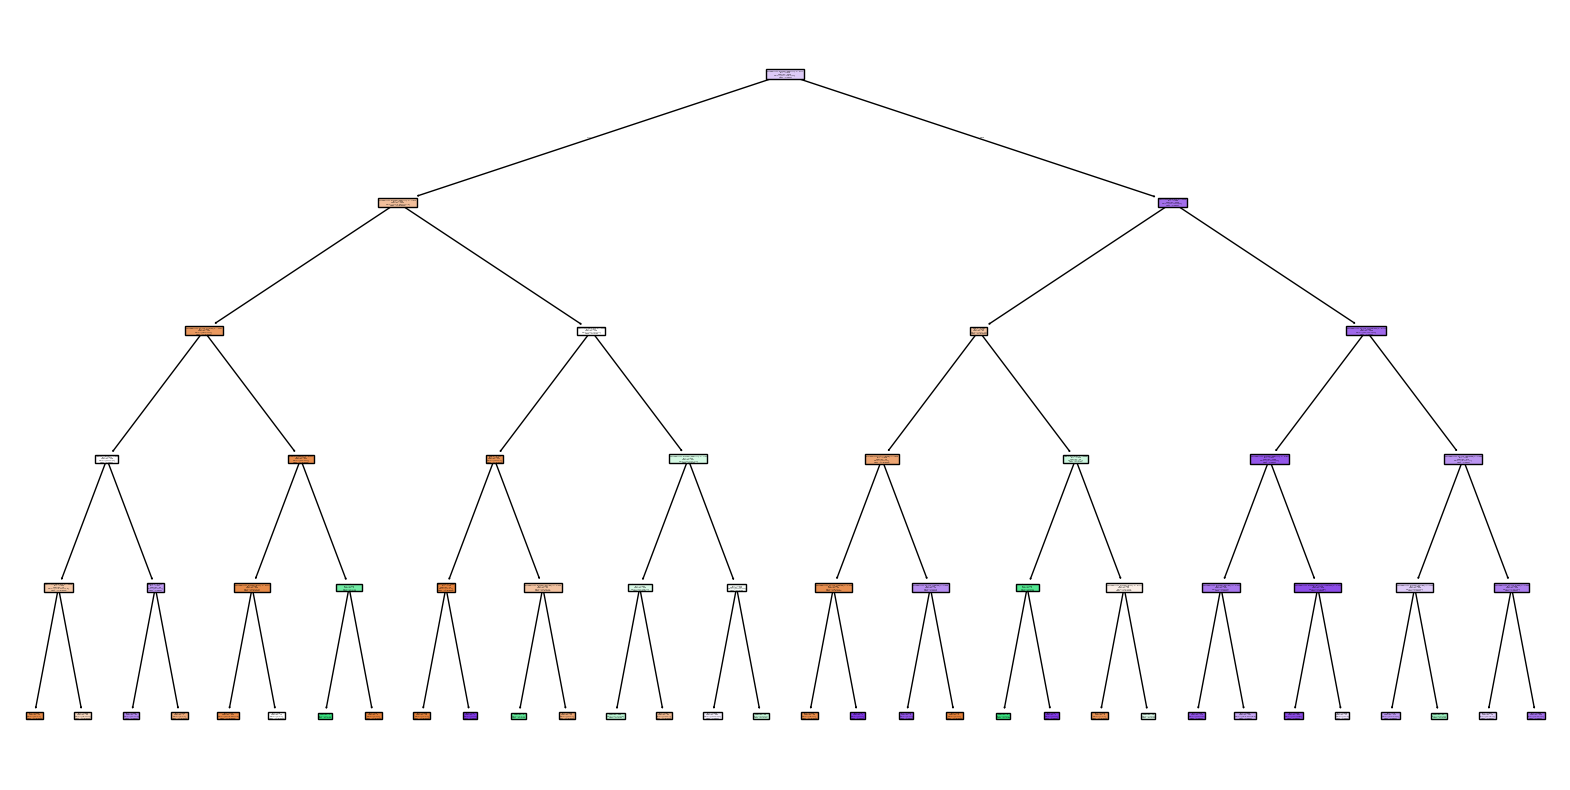

In [36]:
#show the tree
plt.figure(figsize=(20,10))
plot_tree(dt_grid.best_estimator_, filled=True, feature_names=X.columns, class_names=['No Dropout', 'Enrolled', 'Dropout'])
plt.show()

In [45]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators':[100,150,200,300], 'max_depth':[5,6,7,8,9,10], 'min_samples_split':[20,30,40,50,60]}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_split': [20, 30, ...], 'n_estimators': [100, 150, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


Random Forest Accuracy: 0.7706214689265537
Random Forest Train Accuracy: 0.8392201186775925
Confusion Matrix:
 [[221  12  51]
 [ 43  43  73]
 [ 10  14 418]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79       284
           1       0.62      0.27      0.38       159
           2       0.77      0.95      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.66      0.67       885
weighted avg       0.76      0.77      0.75       885



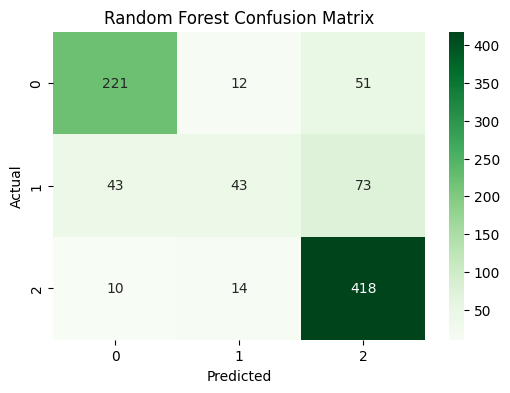

In [46]:
#test and evaluate random forest
y_pred_rf = rf_grid.predict(X_test)
y_train_pred_rf = rf_grid.predict(X_train)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
#visual heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
# AdaBoost
ada = AdaBoostClassifier(random_state=42)
ada_params = {'n_estimators':[100,150,200], 'learning_rate':[0.01,0.1,0.5,1.0], 'estimator':[DecisionTreeClassifier(max_depth=1)], 'random_state':[42]}
ada_grid = GridSearchCV(ada, ada_params, cv=5, scoring='accuracy')
ada_grid.fit(X_train, y_train)

,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'estimator': [DecisionTreeC...r(max_depth=1)], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [100, 150, ...], 'random_state': [42]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


AdaBoost Accuracy: 0.7457627118644068
AdaBoost Train Accuracy: 0.7552981068098333
Confusion Matrix:
 [[221  22  41]
 [ 56  45  58]
 [ 21  27 394]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.78      0.76       284
           1       0.48      0.28      0.36       159
           2       0.80      0.89      0.84       442

    accuracy                           0.75       885
   macro avg       0.67      0.65      0.65       885
weighted avg       0.72      0.75      0.73       885



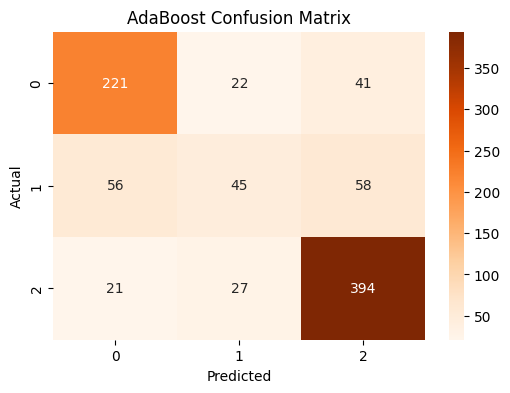

In [50]:
#evaluate adaboost
y_pred_ada = ada_grid.predict(X_test)
y_train_pred_ada = ada_grid.predict(X_train)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Train Accuracy:", accuracy_score(y_train, y_train_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("Classification Report:\n", classification_report(y_test, y_pred_ada))
#visual heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Oranges')
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_params = {'n_estimators':[100,200], 'learning_rate':[0.01,0.1,0.3,0.5], 'max_depth':[3,5,6,7,10], 'eval_metric':['logloss']}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'eval_metric': ['logloss'], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


XGBoost Accuracy: 0.7638418079096045
XGBoost Train Accuracy: 0.8556089290760102
Confusion Matrix:
 [[208  34  42]
 [ 36  65  58]
 [ 16  23 403]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.73      0.76       284
           1       0.53      0.41      0.46       159
           2       0.80      0.91      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



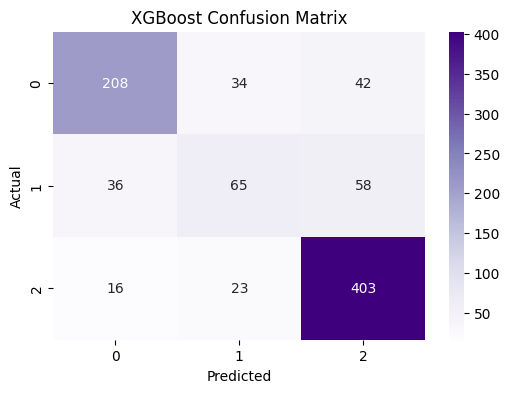

In [53]:
#evaluate xgboost
y_pred_xgb = xgb_grid.predict(X_test)
y_train_pred_xgb = xgb_grid.predict(X_train)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
#visual heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()